---
title: "Weighted Least-Squares State Estimation"
description: "Estimate the same grid from redundant noisy measurements."
author: "EulerLettersAI"
date: last-modified
jupyter: python3
format:
  html:
    code-fold: false
    code-links:
      - text: Download notebook
        icon: file-earmark-arrow-down
        href: 2.0-wls-state-estimation.ipynb?download=1
execute:
  echo: true
  warning: false
---

## Setup

This notebook requires Python 3.11 and the packages below. Run this command in a notebook cell once if they are not already installed:

```python
%pip install matplotlib==3.10.8 numpy==2.2.6 pandas==2.3.3 pandapower==3.2.1
```

Restart the kernel after installation, then run the notebook from top to bottom.

In [1]:
#| label: setup
#| echo: true

%matplotlib inline
import json
import logging
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pandapower as pp
import pandapower.networks as pn
from pandapower.plotting import simple_plot

logging.getLogger("pandapower").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message=".*numba cannot be imported.*")
pd.options.display.float_format = "{:,.5f}".format

from pandapower.estimation import chi2_analysis, estimate

## Learning objectives

You will formulate nonlinear weighted least squares (WLS), construct a redundant measurement set, estimate bus-voltage states with pandapower, calculate flows from the estimated state, and compare estimation with power flow.

In [2]:
#| label: grid-builder
#| echo: true

def build_ieee_14_grid():
    # Load pandapower's built-in IEEE 14-bus benchmark without changing it.
    return pn.case14()


def draw_grid(net, title="The pandapower IEEE 14-bus grid"):
    # case14 includes geographic bus coordinates; simple_plot is a pandapower tool.
    ax = simple_plot(
        net, show_plot=False, bus_size=0.7, line_width=2.0,
        ext_grid_size=1.1, trafo_size=0.8, plot_loads=True,
        plot_gens=True, plot_sgens=True, load_size=0.8,
        gen_size=0.8, sgen_size=0.8,
    )
    for bus, row in net.bus.iterrows():
        point = json.loads(row.geo)["coordinates"]
        ax.annotate(f"Bus {bus + 1}", point, xytext=(7, 7),
                    textcoords="offset points", fontsize=10)
    ax.set_title(title)
    return ax

In [3]:
#| label: measurement-builder
#| echo: true

def add_redundant_measurements(net, seed=7):
    # Create reproducibly noisy, redundant SCADA-style measurements.
    rng = np.random.default_rng(seed)
    sigma_v, sigma_power = 0.005, 0.8

    # One voltage-magnitude measurement at every bus.
    for bus in net.bus.index:
        value = net.res_bus.at[bus, "vm_pu"] + rng.normal(0, sigma_v)
        pp.create_measurement(net, "v", "bus", value, sigma_v, bus,
                              name=f"V{bus}")

    # Active and reactive injection measurements at every bus.
    for bus in net.bus.index:
        for kind, column in [("p", "p_mw"), ("q", "q_mvar")]:
            value = net.res_bus.at[bus, column] + rng.normal(0, sigma_power)
            pp.create_measurement(net, kind, "bus", value, sigma_power, bus,
                                  name=f"{kind.upper()}{bus}_inj")

    # Active and reactive flow at every line's from end.
    for line in net.line.index:
        for kind, column in [("p", "p_from_mw"), ("q", "q_from_mvar")]:
            value = net.res_line.at[line, column] + rng.normal(0, sigma_power)
            pp.create_measurement(net, kind, "line", value, sigma_power,
                                  line, side="from",
                                  name=f"{kind.upper()}_{net.line.at[line, 'name']}_from")
    # Active and reactive flow at every transformer's high-voltage end.
    for trafo in net.trafo.index:
        for kind, column in [("p", "p_hv_mw"), ("q", "q_hv_mvar")]:
            value = net.res_trafo.at[trafo, column] + rng.normal(0, sigma_power)
            pp.create_measurement(net, kind, "trafo", value, sigma_power,
                                  trafo, side="hv",
                                  name=f"{kind.upper()}_T{trafo}_hv")
    return net

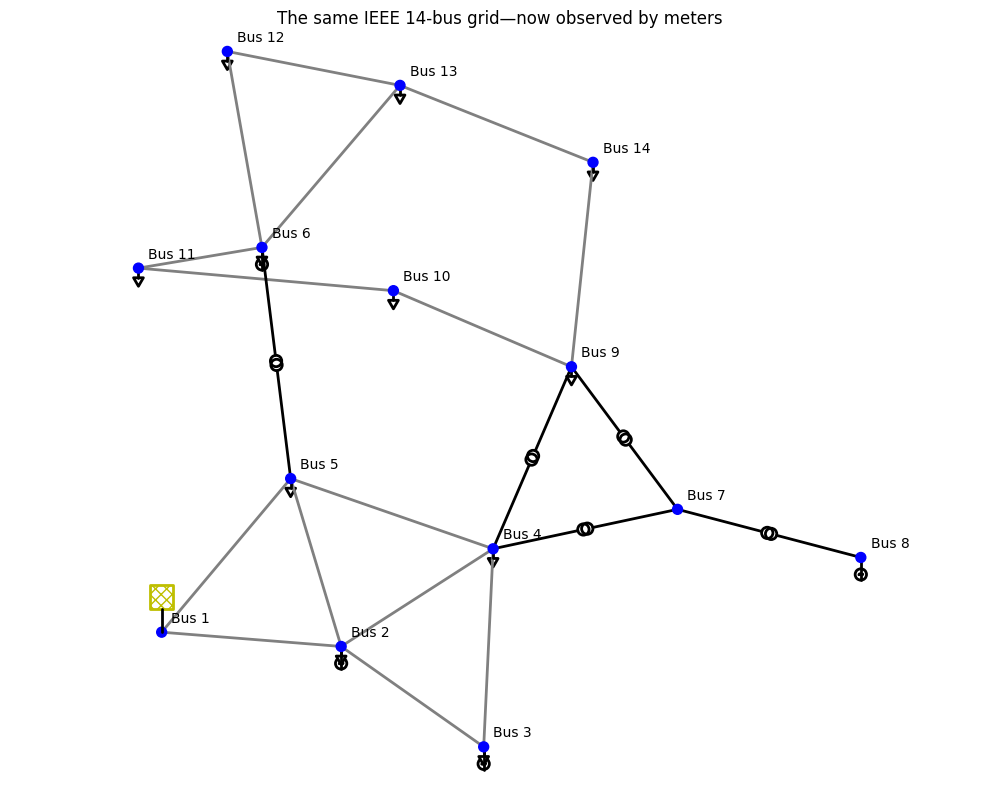

In [4]:
#| label: draw-grid
#| echo: true

net = build_ieee_14_grid()
draw_grid(net, "The same IEEE 14-bus grid—now observed by meters")
plt.show()

## 1. The engineering question

The network topology and parameters are known, but the true bus voltages and injections are not directly available. A SCADA system supplies noisy voltage, injection, and line-flow measurements with known standard deviations.

**Question.** What set of bus voltage magnitudes and phase angles best explains all measurements simultaneously? From that estimated state, what are the line flows and loadings? Are the residuals consistent with the stated meter accuracy?

Unlike load flow, state estimation does **not** treat every load and generator injection as exact. Redundancy lets inconsistent measurements be reconciled and later supports bad-data detection.

## 2. WLS mathematical model

For $n$ buses, choose the reference angle and define the $2n-1$ state vector

$$x=[\theta_2,\ldots,\theta_n,|V_1|,\ldots,|V_n|]^T.$$

Each measurement is a nonlinear function of the state:

$$z=h(x)+e,\qquad e\sim\mathcal N(0,R),\qquad
R=\operatorname{diag}(\sigma_1^2,\ldots,\sigma_m^2).$$

WLS minimizes standardized squared residuals,

$$\hat x=\arg\min_x J(x),\qquad
J(x)=[z-h(x)]^T R^{-1}[z-h(x)].$$

At iteration $k$, with $H=\partial h/\partial x$, solve the Gauss–Newton normal equations

$$
(H^TR^{-1}H)\Delta x=H^TR^{-1}[z-h(x^{(k)})],
\qquad x^{(k+1)}=x^{(k)}+\Delta x.
$$

Smaller $\sigma_i$ gives measurement $i$ more weight. A solution requires the gain matrix $G=H^TR^{-1}H$ to be nonsingular: this is the local numerical observability condition.

## 3. Create redundant measurements

A simulation needs hidden “truth” to synthesize meters. We first run a power flow, sample measurement noise with a fixed seed, and then estimate from **only** the stored measurements. In a real control room the physical system supplies those meter values; the true state is unavailable.

There are $2(14)-1=27$ voltage-state unknowns and 82 measurements: 14 voltage magnitudes, 28 bus injections, 30 line-end flows, and 10 transformer-end flows.

In [5]:
#| label: create-measurements
#| echo: true

pp.runpp(net, calculate_voltage_angles=True, numba=False)
truth_bus = net.res_bus[["vm_pu", "va_degree"]].copy()
truth_line = net.res_line[["p_from_mw", "q_from_mvar", "loading_percent"]].copy()
add_redundant_measurements(net, seed=7)

print(f"State variables: {2 * len(net.bus) - 1}")
print(f"Measurements:   {len(net.measurement)}")
net.measurement[["name", "measurement_type", "element_type", "value", "std_dev"]].head(10)

State variables: 27
Measurements:   82


,name,measurement_type,element_type,value,std_dev
0,V0,v,bus,1.06001,0.00500
1,V1,v,bus,1.04649,0.00500
2,V2,v,bus,1.00863,0.00500
3,V3,v,bus,1.01322,0.00500
4,V4,v,bus,1.01724,0.00500
5,V5,v,bus,1.06504,0.00500
6,V6,v,bus,1.06182,0.00500
7,V7,v,bus,1.09670,0.00500
8,V8,v,bus,1.05347,0.00500
9,V9,v,bus,1.04788,0.00500


In [6]:
#| label: measurement-counts
#| echo: true

measurement_counts = (
    net.measurement.groupby(["element_type", "measurement_type"])
    .size().rename("count").to_frame()
)
measurement_counts

count
element_type measurement_type       
bus          p                    14
             q                    14
             v                    14
line         p                    15
             q                    15
trafo        p                     5
             q                     5

## 4. Estimate the state with pandapower WLS

In [7]:
#| label: run-wls
#| echo: true

result = estimate(net, algorithm="wls", init="flat", tolerance=1e-7,
                  maximum_iterations=50)
result

{'success': True,
 'num_iterations': 5,
 'objective_function_value': None,
 'time': '2026-08-10 00:51:46'}

In [8]:
#| label: compare-states
#| echo: true

state_comparison = pd.DataFrame({
    "true_vm_pu": truth_bus.vm_pu,
    "estimated_vm_pu": net.res_bus_est.vm_pu,
    "vm_error_pu": net.res_bus_est.vm_pu - truth_bus.vm_pu,
    "true_angle_deg": truth_bus.va_degree,
    "estimated_angle_deg": net.res_bus_est.va_degree,
    "angle_error_deg": net.res_bus_est.va_degree - truth_bus.va_degree,
}, index=net.bus.name)
state_comparison

,true_vm_pu,estimated_vm_pu,vm_error_pu,true_angle_deg,estimated_angle_deg,angle_error_deg
name,,,,,,
1,1.04500,1.04078,-0.00422,-4.98259,-5.01639,-0.03380
2,1.01000,1.00625,-0.00375,-12.72510,-12.82244,-0.09734
3,1.01767,1.01426,-0.00341,-10.31290,-10.42095,-0.10805
4,1.01951,1.01557,-0.00394,-8.77385,-8.85680,-0.08294
5,1.07000,1.06606,-0.00394,-14.22095,-14.35326,-0.13231
6,1.06152,1.06208,0.00057,-13.35963,-13.54618,-0.18656
7,1.09000,1.08796,-0.00204,-13.35963,-13.59177,-0.23214
8,1.05593,1.06229,0.00636,-14.93852,-15.16247,-0.22395
9,1.05098,1.05391,0.00293,-15.09729,-15.28203,-0.18475


## 5. Calculate flows from the estimated state

    Once $\hat x$ is known, pandapower evaluates the network equations to obtain estimated injections and branch flows—even where no flow meter exists.

In [9]:
#| label: estimated-flows
#| echo: true

estimated_flows = net.res_line_est[[
    "p_from_mw", "q_from_mvar", "p_to_mw", "q_to_mvar", "loading_percent"
]].copy()
estimated_flows.index = net.line.name
estimated_flows

,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,loading_percent
name,,,,,
None,156.41509,-20.98305,-152.10168,28.35225,1.51043
None,75.51072,3.54220,-72.72577,2.67697,0.72383
None,73.19814,3.30669,-70.85985,1.95487,0.71158
None,56.30855,-2.08766,-54.60759,3.65849,0.54687
None,41.63610,0.94018,-40.72051,-1.80297,0.40541
None,-23.10002,4.21228,23.46880,-4.57746,0.23813
None,-61.31740,17.19756,61.84370,-15.53745,0.63422
None,7.31078,2.39327,-7.26133,-2.28970,0.07289
None,7.97199,2.96358,-7.89376,-2.80076,0.08059


In [10]:
#| label: estimated-transformer-flows
#| echo: true

estimated_transformer_flows = net.res_trafo_est[[
    "p_hv_mw", "q_hv_mvar", "p_lv_mw", "q_lv_mvar", "loading_percent"
]].copy()
estimated_transformer_flows.index = [f"Transformer {i}" for i in net.trafo.index]
estimated_transformer_flows

,p_hv_mw,q_hv_mvar,p_lv_mw,q_lv_mvar,loading_percent
Transformer 0,28.71572,-11.61806,-28.71572,13.48379,0.32044
Transformer 1,16.52545,-2.24779,-16.52545,3.65978,0.17097
Transformer 2,44.15035,12.32894,-44.15035,-7.86905,0.46302
Transformer 3,0.52191,-15.60199,-0.52191,15.98254,0.16153
Transformer 4,28.92727,0.21014,-28.92727,0.60598,0.29226


In [11]:
#| label: compare-flows
#| echo: true

flow_comparison = pd.DataFrame({
    "true_p_from_mw": truth_line.p_from_mw,
    "estimated_p_from_mw": net.res_line_est.p_from_mw,
    "error_mw": net.res_line_est.p_from_mw - truth_line.p_from_mw,
}, index=net.line.name)
flow_comparison

,true_p_from_mw,estimated_p_from_mw,error_mw
name,,,
None,NaN,NaN,NaN
None,NaN,NaN,NaN
None,NaN,NaN,NaN
None,NaN,NaN,NaN
None,NaN,NaN,NaN
None,NaN,NaN,NaN
None,NaN,NaN,NaN
None,NaN,NaN,NaN
None,NaN,NaN,NaN


## 6. Residual consistency

The minimized WLS statistic is compared with a $\chi^2$ threshold with approximately $m-(2n-1)$ degrees of freedom. A rejection means at least one of the meter-error model, topology, or network parameters is questionable; it does not identify the culprit by itself.

In [12]:
#| label: chi-square-test
#| echo: true

bad_data_detected = chi2_analysis(net, init="flat", tolerance=1e-7,
                                  maximum_iterations=50)
print(f"Chi-square test flags bad data: {bad_data_detected}")

Chi-square test flags bad data: True


## 7. Power flow versus state estimation

| Feature | Power flow | State estimation |
|---|---|---|
| Main question | What state follows from specified injections/set points? | What state best explains measured data? |
| Inputs | Network plus assumed exact operating data | Network plus noisy, redundant meters |
| Equations | $g(x)=0$ | $\min [z-h(x)]^TR^{-1}[z-h(x)]$ |
| Typical solver | Newton–Raphson root finding | Gauss–Newton WLS |
| Redundancy | Not required | Essential for robustness and bad-data checks |
| Output | Predicted operating point | Reconstructed operating point and residuals |

### Check your understanding

1. Double every meter standard deviation. Does the WLS point estimate change? What changes statistically?
2. Add 8 MW to one active-power meter. Does the $\chi^2$ test flag the data?
3. Remove measurements until WLS fails. Is a raw count of 27 measurements sufficient to guarantee observability?